# Computing Optimal Feeding Policies for a Semi-Batch Reactor

The objective is to determine the optimal feed rate profile for an isothermal semi-batch reactor with parallel reactions and selectivity constraints:
* __Reactions__: ${\sf A} + {\sf B} \stackrel{{\sf R}_1}{\longrightarrow} {\sf C}$, $\quad  2{\sf B} \stackrel{{\sf R}_2}{\longrightarrow} {\sf D}$
* __Operation Mode__: Semi-batch (no outlet), isothermal
* __Control__: Feed rate of ${\sf B}$ in the range $0$--$0.001\ \rm L\ min^{-1}]$
* __Objective__: Maximal production of ${\sf C}$ at a fixed final time of $50\ \rm min$
* __Terminal Constraint 1__: Maximal concentration of ${\sf B}$ at final time of $0.02\ \rm mol\ L^{-1}$
* __Terminal Constraint 2__: Maximal concentration of ${\sf D}$ at final time of $0.005\ \rm mol\ L^{-1}$

The following dynamic model is derived from mass-balance considerations:
\begin{align*}
\dot{c}_{\sf A}(t) =\ & -k_1\,c_{\sf A}(t)\,c_{\sf B}(t) - \frac{F(t)}{V(t)}\,c_{\sf A}(t); & c_{\sf A}(0) =\ & c_{\sf A}^0 \\
\dot{c}_{\sf B}(t) =\ & -k_1\,c_{\sf A}(t)\,c_{\sf B}(t) - 2\,k_2\,[c_{\sf B}(t)]^2 + \frac{F(t)}{V(t)}\left[c^{\rm in}_{\sf B}-c_{\sf B}(t)\right]; & c_{\sf B}(0) =\ & c_{\sf B}^0 \\
\dot{V}(t) =\ & F(t); & V(0) =\ & V^0,
\end{align*}
where $c_{\sf X}$ stand for the concentration of a species ${\sf X}\in\{{\sf A},{\sf B}\}$; $V$, the reactor volume; $F$, the feed rate of ${\sf B}$; $c^{\rm in}_{\sf B}$, the inlet concentration of ${\sf B}$; and $k_1$, $k_2$ the kinetic rates of reactions ${\sf R}_1$ and ${\sf R}_2$, respectively. Moreover, by mass conservation, the concentrations of species ${\sf C}$ and ${\sf D}$ are calculated as:
\begin{align*}
c_{\sf C}(t) =\ & \frac{1}{V(t)} \left[c_{\sf A}^0\,V^0-c_{\sf A}(t)\, V(t)\right] \\
c_{\sf D}(t) =\ & \frac{1}{2\,V(t)} \left( \left[c_{\sf A}(t) +c_{\sf B}^{\rm in}- c_{\sf B}(t)\right] V(t) - \left[c_{\sf A}^0 +c_{\sf B}^{\rm in}- c_{\sf B}^0\right] V^0 \right).
\end{align*}
Numerical values for the model parameters and initial conditions are given in the following table:

Parameter | Value    | $\qquad$ | Initial Condition | Value
:-------- | :------ | -- | :--------------- | :---
$k_1\ (\rm L\ mol^{-1}\ min^{-1})$ | $0.053$ | $\qquad$ | $c_{\sf A}^0\ (\rm mol\ L^{-1})$ | $0.72$
$k_2\ (\rm L\ mol^{-1}\ min^{-1})$ | $0.128$ | $\qquad$ | $c_{\sf B}^0\ (\rm mol\ L^{-1})$ | $0.05$
$c_{\sf B}^{\rm in} (\rm \rm mol\ L^{-1})$ | $5.0$ | $\qquad$ | $V^0\ (\rm L)$ | $1.0$

A mathematical formulation of the constrained dynamic optimization problem is the following:
\begin{align*}
\max_{F(t), 0\leq t\leq t_{\rm f}}\ & c_{\sf A}^0\,V^0-c_{\sf A}(t_{\rm f})\, V(t_{\rm f})\\[-.15em]
\text{s.t.} \quad & \dot{c}_{\sf A}(t) = -k_1\,c_{\sf A}(t)\,c_{\sf B}(t) - \frac{F(t)}{V(t)}\,c_{\sf A}(t); \quad c_{\sf A}(0) = c_{\sf A}^0 \\[-.25em]
& \dot{c}_{\sf B}(t) = -k_1\,c_{\sf A}(t)\,c_{\sf B}(t) - 2\,k_2\,[c_{\sf B}(t)]^2 + \frac{F(t)}{V(t)}\left[c^{\rm in}_{\sf B}-c_{\sf B}(t)\right]; \quad c_{\sf B}(0) = c_{\sf B}^0 \\[-.25em]
& \dot{V}(t) = F(t); \quad V(0) = V^0\\
& 2\,V(t)\,c_{\sf D}(t) = \left[c_{\sf A}(t) +c_{\sf B}^{\rm in}- c_{\sf B}(t)\right] V(t) - \left[c_{\sf A}^0 +c_{\sf B}^{\rm in}- c_{\sf B}^0\right] V^0\\
& c_{\sf B}(t_{\rm f}) \leq 0.02\\
& c_{\sf D}(t_{\rm f})  \leq 0.005\\
& 0 \leq F(t) \leq 0.001, \forall t\in [0,t_{\rm f}]
\end{align*}

In [1]:
import pymc
import cronos
import canon
import numpy as np

In [2]:
IVPDAG = pymc.FFGraph()

# State
cA  = pymc.FFVar(IVPDAG, "cA")
cB  = pymc.FFVar(IVPDAG, "cB")
V   = pymc.FFVar(IVPDAG, "V" )

# Control
NS = 40  # Number of control stages
F = [ pymc.FFVar(IVPDAG,"F"+str(i)) for i in range(NS) ]

# Constant
k1   = pymc.FFVar(IVPDAG, "k1"  )
k2   = pymc.FFVar(IVPDAG, "k2"  )
cBin = pymc.FFVar(IVPDAG, "cBin")
cA0  = pymc.FFVar(IVPDAG, "cA0" )
cB0  = pymc.FFVar(IVPDAG, "cB0" )
V0   = pymc.FFVar(IVPDAG, "V0"  )

In [3]:
IVP = cronos.ODESLV()
IVP.set_dag( IVPDAG )

TF = 50
TS = np.linspace( 0, TF, NS+1 )
IVP.set_time( TS.tolist() )

IVP.set_parameter( F )
IVP.set_constant( [k1, k2, cBin, cA0, cB0, V0] )
IVP.set_state( [cA, cB, V] )

IVP.set_differential( [ [- k1*cA*cB - F[i]/V*cA,
                         - k1*cA*cB - k2*cB**2 + F[i]/V*(cBin-cB),
                         F[i]                                     ] for i in range(NS) ] )
IVP.set_initial( [cA0, cB0, V0] )

nC = cA0*V0 - cA*V
cD = ((cA+cBin-cB)*V - (cA0+cBin-cB0)*V0) / (2*V)
IVP.add_function( NS, [nC, cB, cD] ) # batch-end cost and constraints 
#print( IVP.eqn_function )

IVP.setup()

In [4]:
IVP.options.DISPLEVEL = 0 # displays numerical integration results
IVP.options.RESRECORD = 200 # record 200 points along time horizon

F0 = [0e-4 for i in range(NS)]
IVP.solve_state( F0, [0.053, 0.128, 5.0, 0.72, 0.05, 1.0] )
#IVP.solve_sensitivity( F0, [0.053, 0.128, 5.0, 0.72, 0.05, 1.0] )
#IVP.solve_state( F0, [0.053, 0.128, 5.0, 0.72, 0.05, 1.0] )


<Status.Normal: 0>

In [5]:
results = []
for rec in IVP.results_state:
    [rec_cC, rec_cD] = IVPDAG.eval( [(cA0*V0 - cA*V) / V, cD], [cA, cB, V, k1, k2, cBin, cA0, cB0, V0], rec.x + [0.053, 0.128, 5.0, 0.72, 0.05, 1.0] )
    results.append( [rec.t] + rec.x + [rec_cC, rec_cD] )
results = np.array( results ) # convert list into numpy array
print( results )

[[0.00000000e+00 7.20000000e-01 5.00000000e-02 1.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [6.25000000e-03 7.19988077e-01 4.99860779e-02 1.00000000e+00
  1.19227809e-05 9.99648754e-07]
 [1.25000000e-02 7.19976158e-01 4.99721601e-02 1.00000000e+00
  2.38423095e-05 1.99878282e-06]
 ...
 [4.99875000e+01 6.80710106e-01 6.94239312e-03 1.00000000e+00
  3.92898939e-02 1.88385651e-03]
 [4.99937500e+01 6.80708541e-01 6.94078934e-03 1.00000000e+00
  3.92914591e-02 1.88387579e-03]
 [5.00000000e+01 6.80706976e-01 6.93918595e-03 1.00000000e+00
  3.92930239e-02 1.88389505e-03]]


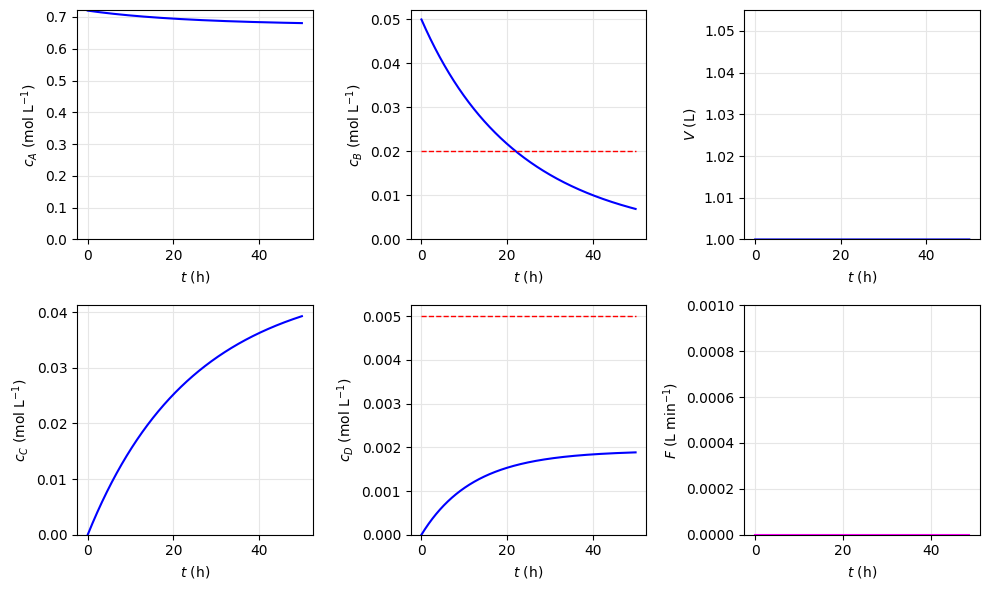

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

axes[0,0].plot( results[:,0], results[:,1], color="blue" )
axes[0,0].grid(color='0.9')
axes[0,0].set(xlabel="$t$ (h)")
axes[0,0].set(ylabel="$c_A$ (mol L$^{-1}$)")
axes[0,0].set_ylim(ymin=0)

axes[0,1].plot( results[:,0], results[:,2], color="blue" )
axes[0,1].hlines(y=0.02, xmin=0, xmax=50, linewidth=1, linestyle='--', color="red")
axes[0,1].grid(color='0.9')
axes[0,1].set(xlabel="$t$ (h)")
axes[0,1].set(ylabel="$c_B$ (mol L$^{-1}$)")
axes[0,1].set_ylim(ymin=0)

axes[1,0].plot( results[:,0], results[:,4], color="blue" )
axes[1,0].grid(color='0.9')
axes[1,0].set(xlabel="$t$ (h)")
axes[1,0].set(ylabel="$c_C$ (mol L$^{-1}$)")
axes[1,0].set_ylim(ymin=0)

axes[1,1].plot( results[:,0], results[:,5], color="blue" )
axes[1,1].hlines(y=0.005, xmin=0, xmax=50, linewidth=1, linestyle='--', color="red")
axes[1,1].grid(color='0.9')
axes[1,1].set(xlabel="$t$ (h)")
axes[1,1].set(ylabel="$c_D$ (mol L$^{-1}$)")
axes[1,1].set_ylim(ymin=0)

axes[0,2].plot( results[:,0], results[:,3], color="blue" )
axes[0,2].grid(color='0.9')
axes[0,2].set(xlabel="$t$ (h)")
axes[0,2].set(ylabel="$V$ (L)")
axes[0,2].set_ylim(ymin=1.0)

axes[1,2].step( TS[0:NS], F0, where='post', color="magenta" )
axes[1,2].grid(color='0.9')
axes[1,2].set(xlabel="$t$ (h)")
axes[1,2].set(ylabel="$F$ (L min$^{-1}$)")
axes[1,2].set_ylim(ymin=0.0)
axes[1,2].set_ylim(ymax=0.001)

[ fig.delaxes(ax) for ax in axes.flatten() if not ax.has_data() ]
fig.tight_layout()


In [7]:
help(IVP.options)


Help on Options in module cronos object:

class Options(pybind11_builtins.pybind11_object)
 |  Method resolution order:
 |      Options
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(...)
 |      __init__(*args, **kwargs)
 |      Overloaded function.
 |
 |      1. __init__(self: cronos.ODESLV.Options) -> None
 |
 |      2. __init__(self: cronos.ODESLV.Options, arg0: cronos.ODESLV.Options) -> None
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  ASACHKPT
 |      Number of steps between each check point for ASA [Default: 2000]
 |
 |  ASAINTERP
 |      ASA interpolation strategy [Default: HERMITE]
 |
 |  ATOL
 |      Absolute integration tolerance [Default: 1e-9]
 |
 |  ATOLB
 |      Absolute integration tolerance for ASA [Default: 1e-9]
 |
 |  ATOLS
 |      Absolute integration tolerance for FSA [Default: 1e-9]
 |
 |  AUTOTOLS
 |      Whether to set autom

In [8]:
# Define OCP
OCP = canon.NLPSLV()
OCP.set_dag( IVPDAG )
OCP.set_parameter( [k1, k2, cBin, cA0, cB0, V0] )
OCP.add_decision( F, 0e0, 1e-3 )


IVP.options.ATOL   = 1e-10
IVP.options.RTOL   = 1e-10
IVP.options.ATOLS  = 1e-10
IVP.options.RTOLS  = 1e-10
IVP.options.ATOLB  = 1e-10
IVP.options.RTOLB  = 1e-10
IVP.options.NMAX = 20000
IVP.options.ASACHKPT = 20000
IVP.options.HMIN = 1e-12
IVP.options.LINSOL = IVP.options.DENSE
IVP.options.DISPLEVEL = 0
IVP.options.RESRECORD = 0

OpIVP = cronos.FFODE()
#OpIVP.options.NP2NF = 100
OCP.set_objective( OCP.MAX, OpIVP( 0, F, [k1, k2, cBin, cA0, cB0, V0], IVP ) )
OCP.add_constraint( OCP.LE, OpIVP( 1, F, [k1, k2, cBin, cA0, cB0, V0], IVP ) - 2e-2  )
OCP.add_constraint( OCP.LE, OpIVP( 2, F, [k1, k2, cBin, cA0, cB0, V0], IVP ) - 5e-3 )

OCP.options.FEASTOL     = 1e-9;
OCP.options.OPTIMTOL    = 1e-9;
OCP.options.FCTPREC     = 1e-10;
OCP.options.MAXITER     = 200;
OCP.options.GRADMETH    = OCP.options.FSYM;
OCP.options.GRADCHECK   = 0;
OCP.options.GRADLSEARCH = True;

OCP.setup()
OCP.options.DISPLEVEL = 1;
OCP.solve( F0, [0.053, 0.128, 5.0, 0.72, 0.05, 1.0] )

OCP.options.DISPLEVEL = 0;
OCP.solve( 16, [0.053, 0.128, 5.0, 0.72, 0.05, 1.0] )
print( OCP.solution )

 
 SNMEMA EXIT 100 -- finished successfully
 SNMEMA INFO 104 -- memory requirements estimated

 

 Nonlinear constraints       2     Linear constraints       1
 Nonlinear variables        40     Linear variables         0
 Jacobian  variables        40     Objective variables     40
 Total constraints           3     Total variables         40
 

 
 The user has defined     120   out of     120   first  derivatives
 

 Major Minors     Step   nCon Feasible  Optimal  MeritFunction     nS Penalty
     0     20               1 (0.0E+00) 1.3E-03  3.9293024E-02                  r
     1     27  1.0E+00      2  2.1E-03  3.4E-05  6.4271719E-02                  r
     2     32  1.0E+00      3  4.7E-04  1.6E-05  7.0418252E-02     21         s
     3      7  5.1E-01      5  2.6E-04  3.0E-06  7.0302022E-02     23 2.3E+03
     4      1  1.0E+00      6  1.3E-05  4.8E-07  7.0198297E-02     23 5.9E+03
     5      3  1.0E+00      7  1.7E-07  3.4E-07  7.0202753E-02     21 8.5E+01
     6      1  1.0E+00

In [9]:
IVP.options.RESRECORD = 200 # record 200 points along time horizon
IVP.solve_state( OCP.solution.x, [0.053, 0.128, 5.0, 0.72, 0.05, 1.0] )


<Status.Normal: 0>

In [10]:
results = []
for rec in IVP.results_state:
    [rec_cC, rec_cD] = IVPDAG.eval( [(cA0*V0 - cA*V) / V, cD], [cA, cB, V, k1, k2, cBin, cA0, cB0, V0], rec.x + [0.053, 0.128, 5.0, 0.72, 0.05, 1.0] )
    results.append( [rec.t] + rec.x + [rec_cC, rec_cD] )
results = np.array( results ) # convert list into numpy array
print( results )

[[0.00000000e+00 7.20000000e-01 5.00000000e-02 1.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [6.25000000e-03 7.19988077e-01 4.99860775e-02 1.00000000e+00
  1.19231347e-05 9.99704745e-07]
 [1.25000000e-02 7.19976157e-01 4.99721594e-02 1.00000000e+00
  2.38428521e-05 1.99886868e-06]
 ...
 [4.99875000e+01 6.43302801e-01 2.00091707e-02 1.01010204e+00
  6.94964712e-02 4.99968016e-03]
 [4.99937500e+01 6.43298538e-01 2.00045871e-02 1.01010204e+00
  6.95007345e-02 4.99984027e-03]
 [5.00000000e+01 6.43294276e-01 2.00000047e-02 1.01010204e+00
  6.95049969e-02 5.00000031e-03]]


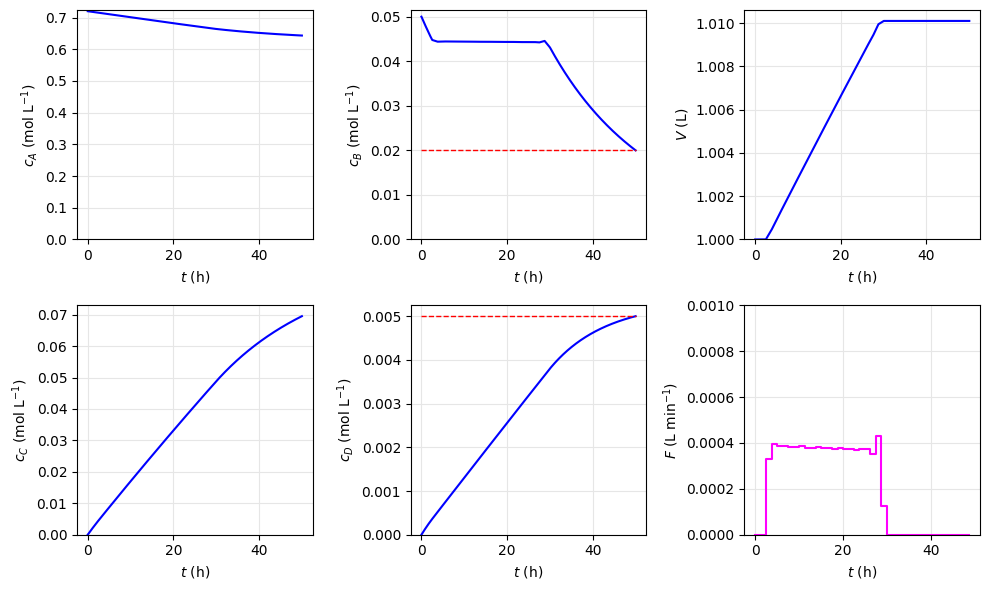

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

axes[0,0].plot( results[:,0], results[:,1], color="blue" )
axes[0,0].grid(color='0.9')
axes[0,0].set(xlabel="$t$ (h)")
axes[0,0].set(ylabel="$c_A$ (mol L$^{-1}$)")
axes[0,0].set_ylim(ymin=0)

axes[0,1].plot( results[:,0], results[:,2], color="blue" )
axes[0,1].hlines(y=0.02, xmin=0, xmax=50, linewidth=1, linestyle='--', color="red")
axes[0,1].grid(color='0.9')
axes[0,1].set(xlabel="$t$ (h)")
axes[0,1].set(ylabel="$c_B$ (mol L$^{-1}$)")
axes[0,1].set_ylim(ymin=0)

axes[1,0].plot( results[:,0], results[:,4], color="blue" )
axes[1,0].grid(color='0.9')
axes[1,0].set(xlabel="$t$ (h)")
axes[1,0].set(ylabel="$c_C$ (mol L$^{-1}$)")
axes[1,0].set_ylim(ymin=0)

axes[1,1].plot( results[:,0], results[:,5], color="blue" )
axes[1,1].hlines(y=0.005, xmin=0, xmax=50, linewidth=1, linestyle='--', color="red")
axes[1,1].grid(color='0.9')
axes[1,1].set(xlabel="$t$ (h)")
axes[1,1].set(ylabel="$c_D$ (mol L$^{-1}$)")
axes[1,1].set_ylim(ymin=0)

axes[0,2].plot( results[:,0], results[:,3], color="blue" )
axes[0,2].grid(color='0.9')
axes[0,2].set(xlabel="$t$ (h)")
axes[0,2].set(ylabel="$V$ (L)")
axes[0,2].set_ylim(ymin=1.0)

axes[1,2].step( TS[0:NS], OCP.solution.x, where='post', color="magenta" )
axes[1,2].grid(color='0.9')
axes[1,2].set(xlabel="$t$ (h)")
axes[1,2].set(ylabel="$F$ (L min$^{-1}$)")
axes[1,2].set_ylim(ymin=0.0)
axes[1,2].set_ylim(ymax=0.001)

[ fig.delaxes(ax) for ax in axes.flatten() if not ax.has_data() ]
fig.tight_layout()
